## 2. Test Model Performance

After completing the training, or with the trained model provided, test δHBV 1.1p below on the evaluation data.

**Note**
- For model evaluation, set `mode: test` in the config, or modify after config dict has been created (see below).
- When evaluating provided models, confirm that `test.test_epoch` in the config corresponds the training epochs completed for the model you want to test (e.g., 50 or 100).
- Default settings with 50 epochs, batch size of 25, and testing window from 1 October 1989 to 30 September 1999 should use ~2.7GB of VRAM. Expect evalutation times of ~5 minutes with an Nvidia RTX 3090 Ti.

### 2.1 Streamflow TEST Mode

In [1]:
import hydrodl2
print(hydrodl2.__file__)

/beegfs/scratch/zhennanshi/hydrodl2/src/hydrodl2/__init__.py


In [2]:
import sys
sys.path.append('../../')
from dmg import ModelHandler
from dmg.core.utils import import_data_loader, import_trainer, print_config, set_randomseed
from example import load_config 
  
# 1. Load configuration dictionary of model parameters and options.
CONFIG_PATH = '../example/conf/config_dhbv_1_1p.yaml'
config = load_config(CONFIG_PATH)
config['mode'] = 'test'
print_config(config)

set_randomseed(config['random_seed'])

# 2. Initialize the differentiable HBV 1.1p model (LSTM + HBV 1.1p).
model = ModelHandler(config, verbose=True)

# 3. Load and initialize a dataset dictionary of NN and HBV model inputs.
data_loader_cls = import_data_loader(config['data_loader'])
data_loader = data_loader_cls(config, test_split=True, overwrite=False)

# 4. Initialize trainer to handle model evaluation.
trainer_cls = import_trainer(config['trainer'])
trainer = trainer_cls(
    config,
    model,
    eval_dataset=data_loader.eval_dataset,
    verbose=False,
)

# 5. Start testing the model.
print('Evaluating model...')
trainer.evaluate()
print(f'Metrics and predictions saved to \n{config['out_path']}')


Current Configuration
  Experiment Mode:    test                
  Model 1:            Hbv_1_1p            

Data Loader
  Data Source:        camels_531          
  Test Range :        1989/10/01          1999/09/30          

Model Parameters
  Train Epochs:       100                 Batch Size:         100                 
  Dropout:            0.5                 Hidden Size:        256                 
  Warmup:             365                 Concurrent Models:  16                  
  Loss Fn:            NseBatchLoss        

Machine
  Use Device:         cuda:0              

Evaluating model...


Metrics and predictions saved to 
/beegfs/scratch/zhennanshi/DM/generic_deltamodel/example/hydrology/output/camels_531/train1999-2008/no_multi/CudnnLstmModel_E100_R365_B100_H256_n16_noLn_noWU_111111/Hbv_1_1p/NseBatchLoss/3dyn/parBETA_parK0_parBETAET/test1989-1999_Ep100


#### 2.1.1 Streamflow TEST Result Original
Once the model has been evaluated, a new directory (e.g., for a model trained for 50 epochs and tested from years 1989-1999), `test1989-1999_ep50/`, will be created in the same directory containing the model files. This path will be populated with...

1. All model outputs (fluxes, states), including the target variable, *streamflow* (`streamflow.npy`),

2. `streamflow_obs.npy`, streamflow observation data for comparison against model predictions,

2. `metrics.json`, containing evaluation metrics accross the test time range for every gage in the dataset,

3. `metrics_agg.json`, containing evaluation metric statistics across all sites (mean, median, standard deviation).

Let's first check the (basin-)aggregated metrics for NSE, KGE, bias, RMSE, and, for both high/low flow regimes, RMSE and absolute percent bias...

In [3]:
import os
from dmg.core.data import load_json
from dmg.core.post import print_metrics
import importlib
import tempfunctions
importlib.reload(tempfunctions)
from tempfunctions import *
#---------------------------
print(f"Evaluation output files saved to: {config['out_path']} \n")

# 1. Load the basin-aggregated evaluation results.
metrics_path = os.path.join(config['out_path'], 'metrics_agg.json')
metrics = load_json(metrics_path)
# print(f"Available metrics: {metrics.keys()} \n")

# 2. Print the evaluation results for all basins 531 or 700+.
metric_names =  [
    # Choose metrics to show.
    'nse', 'kge', 'bias', 'rmse', 'rmse_low', 'rmse_high', 'flv_abs', 'fhv_abs',
]
print_metrics(metrics, metric_names, mode='mean_std', precision=3) #mode = "Median" or "Mean ± Std"
print_metrics(metrics, metric_names, mode='median', precision=3)
 
# 3. Print the evaluation results for selected basins.
RANDOM = False
SEED = config['random_seed']
subset_file = config["observations"]["subset_path"]
with open(subset_file, "r") as f:
    content = f.read().strip()
gage_ids_subset = json.loads(content) if content.startswith("[") else np.loadtxt(subset_file, dtype=int).tolist()  
if config['observations']['name'] == 'camels_671': 
    basin_pool = list(gage_ids)
elif config['observations']['name'] == 'camels_531': 
    basin_pool = list(gage_ids_subset)
selected_basins = selectbasins(RANDOM, SEED)
metrics_path = os.path.join(config['out_path'], 'metrics.json')
metrics = load_json(metrics_path)
print_selected_basin_metrics_from_json(metrics, selected_basins, basin_pool)

Evaluation output files saved to: /beegfs/scratch/zhennanshi/DM/generic_deltamodel/example/hydrology/output/camels_531/train1999-2008/no_multi/CudnnLstmModel_E100_R365_B100_H256_n16_noLn_noWU_111111/Hbv_1_1p/NseBatchLoss/3dyn/parBETA_parK0_parBETAET/test1989-1999_Ep100 

Mean ± Std of Metrics (Prec: 3 digits):
----------------------------------------
Nse: 0.709 ± 0.189
Kge: 0.715 ± 0.214
Bias: 100.057 ± 636.873
Rmse: 1.453 ± 0.993
Rmse_low: 0.108 ± 0.172
Rmse_high: 4.357 ± 3.799
Flv_abs: 453922.896 ± 6115163.811
Fhv_abs: 18.745 ± 12.347
----------------------------------------
Median of Metrics (Prec: 3 digits):
----------------------------------------
Nse: 0.760
Kge: 0.768
Bias: 0.496
Rmse: 1.211
Rmse_low: 0.061
Rmse_high: 3.346
Flv_abs: 41.223
Fhv_abs: 15.789
----------------------------------------

Average over 36 valid selected basins: NSE=0.7479048801792992, KGE=0.738407131560894


#### 2.1.2 Streamflow TEST Result with Modified HBV Class

In [5]:
import os
import json
import numpy as np
import torch
from src.dmg.core.utils import import_data_loader, print_config, print_dataset_info, set_randomseed
# Your HydroDL2 HBV
from hydrodl2.models.hbv import HBV1_1p as h1pp
import torch 

CONFIG_PATH = "../example/conf/config_dhbv_1_1p.yaml"
config = load_config(CONFIG_PATH)
config["mode"] = "test"

set_randomseed(config['random_seed'])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ModelHandler(config, verbose=True)
model.eval()
for m in model.model_dict.values():
    m.eval()
    
print("\n=== Loading TEST dataset via dMG loader ===")
data_loader_cls = import_data_loader(config["data_loader"])
data_loader = data_loader_cls(config, test_split=True, overwrite=False)
dataset = data_loader.eval_dataset
print_dataset_info(dataset)
hbv = h1pp.HBV().to(device)

staind  = -1
tdRep   = [1, 3, 13]
nmul    = config["delta_model"]["phy_model"]["nmul"]
routing = config["delta_model"]["phy_model"]["routing"]
dydrop  = config["delta_model"]["phy_model"]["dy_drop"] # no warm-up in plain test mode

# ============================
# Run for selected basins
# ============================
avg_nse, avg_kge = print_and_average_selected_basin_metrics(
    model=model,
    dataset=dataset,
    selected_basins=selected_basins,
    basin_pool=basin_pool,
    device=device,
    nmul=nmul,
    staind=staind,
    tdRep=tdRep,
    routing=routing,
    dydrop=dydrop,
)
#NSE=0.7446865522199206, KGE=0.733131373307327
#NSE=0.7446865522199206, KGE=0.733131373307327


=== Loading TEST dataset via dMG loader ===

Dataset Inputs
Dataset key    Shape               Description
------------------------------------------------------------
x_phy          (3652, 531, 3)       # [time, basin, forcing_features]
c_phy          (531, 0)             # [basin, attr_features] (no physical attributes here)
x_nn           (3652, 531, 3)       # [time, basin, nn_forcing_features]
c_nn           (531, 35)            # [basin, nn_attr_features]
xc_nn_norm     (3652, 531, 38)      # [time, basin, combined_features]
target         (3652, 531, 1)       # [time, basin, 1] observed streamflow

Sample of target tensor (first 5 timesteps, first basin):
tensor([0.6355, 0.5673, 0.7294, 0.8275, 0.7550], device='cuda:0')
For basin 1073000 ===
the route weights also go here
here t is where it goes!
NSE=0.8689531087875366, KGE=0.8437739069653423
For basin 1078000 ===
the route weights also go here
here t is where it goes!
NSE=0.8518036603927612, KGE=0.7697700674765221
For basin 15

### 2.2 Visualize Model Performance on Tested Original Results

We can use these outputs to visualize δHBV 1.1p's performance with a 
1. Cumulative distribution function (CDF) plot, 

2. CONUS map of gage locations and metric (e.g., NSE) performance.

#### 2.2.1 CDF Plot

The cumulative distribution function (CDF) plot tells us what percentage (CDF on the y-axis) of basins performed at least better than a given metric on the evaluation data.

An example is given below for NSE, but you can change to your preferred metric (see the output from the previous cell), but note some may require changing *xbounds* in `plot_cdf()`.

cleaned metric has # of basins 531


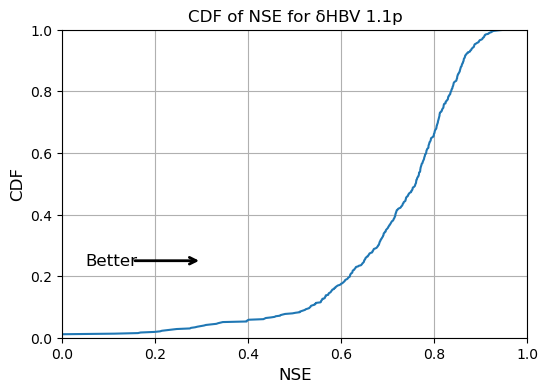

cleaned metric has # of basins 531


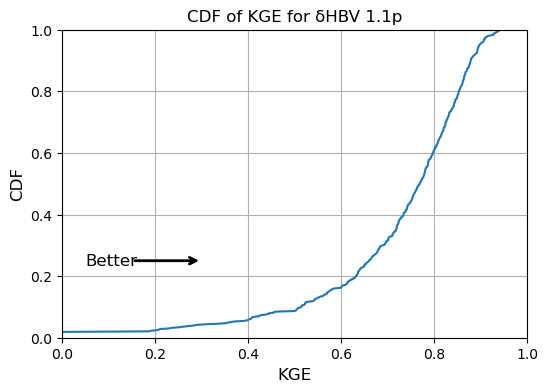

In [5]:
from dmg.core.post import plot_cdf
import importlib
import tempfunctions
importlib.reload(tempfunctions)
from tempfunctions import *
#------------------------------------------#
# Choose the metric to plot. (See available metrics printed above, or in the metrics_agg.json file).
METRICS = ['nse', 'kge']

for METRIC in METRICS: 
    # 1. Load the evaluation metrics.
    metrics_path = os.path.join(config['out_path'], 'metrics.json')
    metrics = load_json(metrics_path)
    metrics = cleannans(metrics, METRIC) ## double check why there are nans
    print("cleaned metric has # of basins", len(metrics[METRIC]))
    
    # 2. Plot the CDF.
    plot_cdf(
        metrics=[metrics],
        metric_names=[METRIC],
        model_labels=['δHBV 1.1p'],
        title=f"CDF of {METRIC.upper()} for δHBV 1.1p",
        xlabel=METRIC.upper(),
        figsize=(6, 4),
        xbounds=(0, 1),
        ybounds=(0, 1),
        show_arrow=True,
    )

#### 2.2.2 Spatial Plot

This plot shows the locations of each basin in the evaluation data, color-coded by performance on a metric. Here we give a plot for NSE, but as before, this can be changed to your preference. (See above; for metrics not valued between 0 and 1, you will need to set `dynamic_colorbar=True` in `geoplot_single_metric` to ensure proper coding.)

Note, you will need to add paths to the CAMELS shapefile, gage IDs, and 531-gage subset which can be found in the [CAMELS download](#before-running).

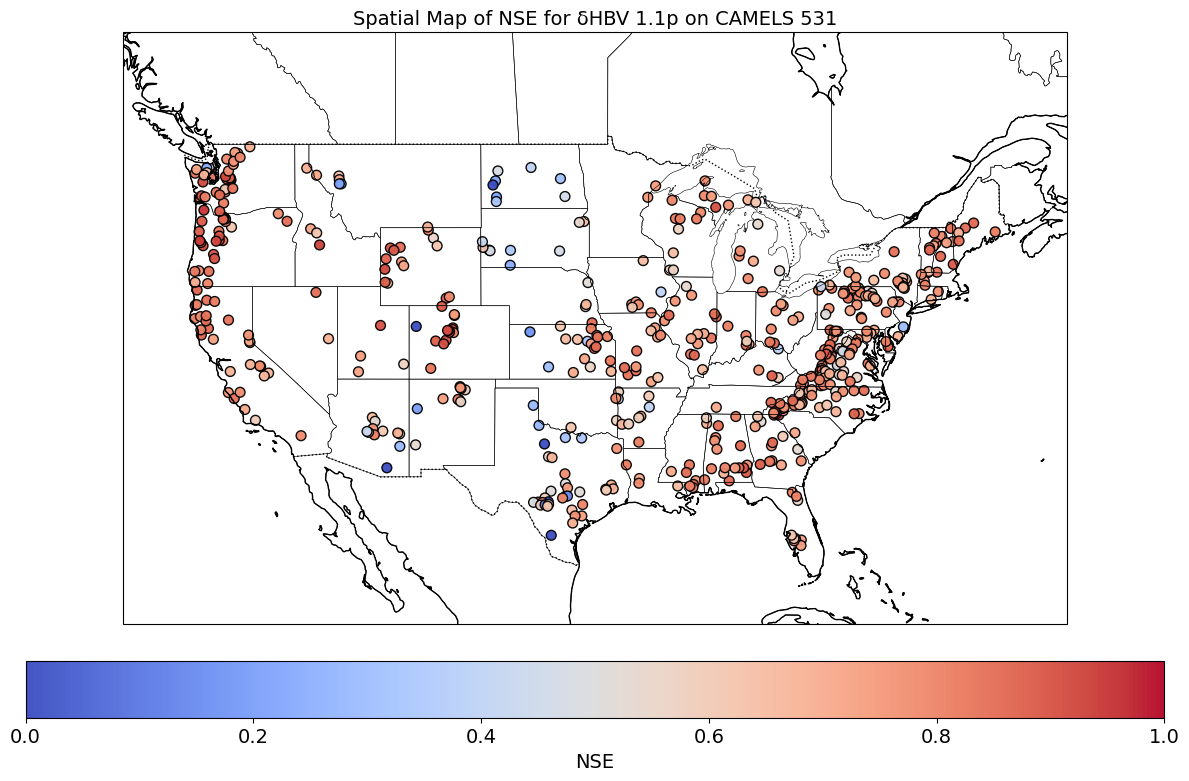

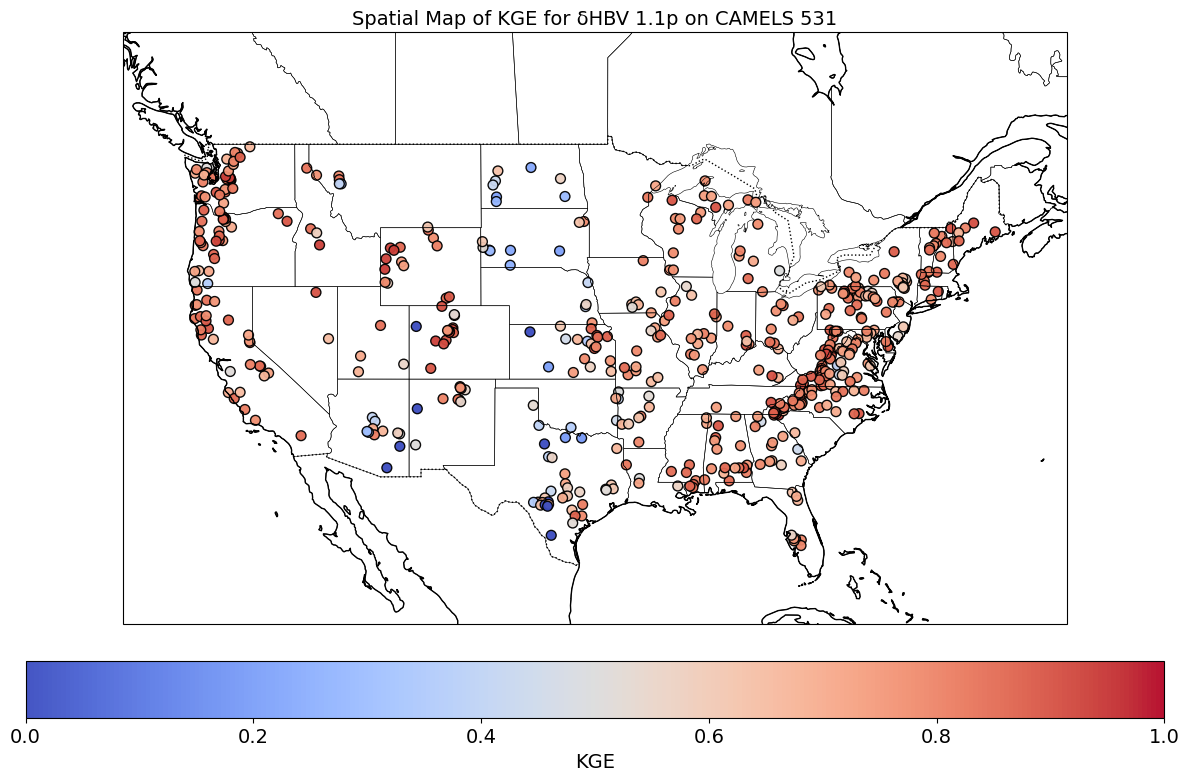

In [6]:
import geopandas as gpd
import numpy as np
import pandas as pd
from dmg.core.data import txt_to_array
from dmg.core.post import geoplot_single_metric

for METRIC in METRICS:
    GAGE_ID_PATH = config['observations']['gage_info']  #./gage_id.npy
    GAGE_ID_531_PATH = config['observations']['subset_path']  #./531sub_id.txt
    SHAPEFILE_PATH = './predownloaded/camels_loc/camels_671_loc.shp' ## zhennan added to his directory

    # 1. Load gage ids + basin shapefile with geocoordinates (lat, long) for every gage.
    gage_ids = np.load(GAGE_ID_PATH, allow_pickle=True)
    gage_ids_subset = txt_to_array(GAGE_ID_531_PATH)
    coords = gpd.read_file(SHAPEFILE_PATH)

    # 2. Format geocoords for 531- and 671-basin CAMELS sets.
    coords_531 = coords[coords['gage_id'].isin(list(gage_ids_subset))].copy()

    coords['gage_id'] = pd.Categorical(coords['gage_id'], categories=list(gage_ids), ordered=True)
    coords_531['gage_id'] = pd.Categorical(coords_531['gage_id'], categories=list(gage_ids_subset), ordered=True)

    coords = coords.sort_values('gage_id')  # Sort to match order of metrics.
    basin_coords_531 = coords_531.sort_values('gage_id')

    # 3. Load the evaluation metrics.
    metrics_path = os.path.join(config['out_path'], 'metrics.json')
    metrics = load_json(metrics_path)

    # 4. Add the evaluation metrics to the basin shapefile.
    if config['observations']['name'] == 'camels_671':
        coords[METRIC] = metrics[METRIC]
        full_data = coords
    elif config['observations']['name'] == 'camels_531':
        coords_531[METRIC] = metrics[METRIC]
        full_data = coords_531
    else:
        raise ValueError(f"Observation data supported: 'camels_671' or 'camels_531'. Got: {config['observations']}")

    # 5. Plot the evaluation results spatially.
    geoplot_single_metric(
        full_data,
        METRIC,
        rf"Spatial Map of {METRIC.upper()} for δHBV 1.1p on CAMELS " \
            f"{config['observations']['name'].split('_')[-1]}",
        dynamic_colorbar=False,
    )